In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Titanic-Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (891, 12)


,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived
0,"Braund, Mr. Owen Harris",male,22.0,1,0,S,A/5 21171,7.2500,NaN,1,3,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C,PC 17599,71.2833,C85,2,1,1
2,"Heikkinen, Miss. Laina",female,26.0,0,0,S,STON/O2. 3101282,7.9250,NaN,3,3,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,S,113803,53.1000,C123,4,1,1
4,"Allen, Mr. William Henry",male,35.0,0,0,S,373450,8.0500,NaN,5,3,0


In [30]:
df.isnull().sum()

Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Embarked         2
Ticket           0
Fare             0
Cabin          687
PassengerId      0
Pclass           0
Survived         0
dtype: int64

In [31]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         891 non-null    str    
 1   Sex          891 non-null    str    
 2   Age          714 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Embarked     889 non-null    str    
 6   Ticket       891 non-null    str    
 7   Fare         891 non-null    float64
 8   Cabin        204 non-null    str    
 9   PassengerId  891 non-null    int64  
 10  Pclass       891 non-null    int64  
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [32]:
df.describe()

,Age,SibSp,Parch,Fare,PassengerId,Pclass,Survived
count,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208,446.000000,2.308642,0.383838
std,14.526497,1.102743,0.806057,49.693429,257.353842,0.836071,0.486592
min,0.420000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400,223.500000,2.000000,0.000000
50%,28.000000,0.000000,0.000000,14.454200,446.000000,3.000000,0.000000
75%,38.000000,1.000000,0.000000,31.000000,668.500000,3.000000,1.000000
max,80.000000,8.000000,6.000000,512.329200,891.000000,3.000000,1.000000


In [33]:
print("Survival Counts:")
print(df["Survived"].value_counts())

print("\nSurvival Percentages:")
print(df["Survived"].value_counts(normalize=True) * 100)

Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentages:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


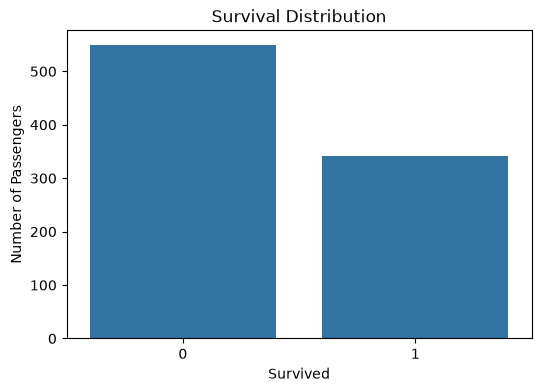

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

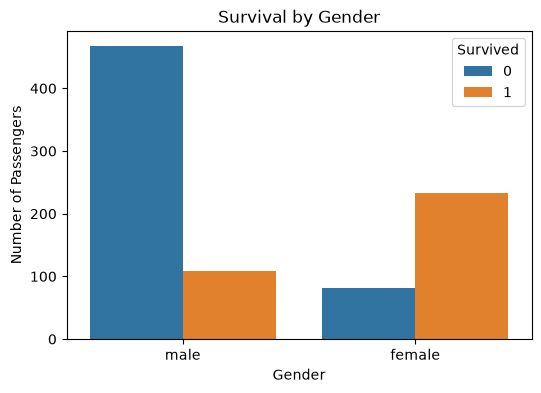

In [35]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

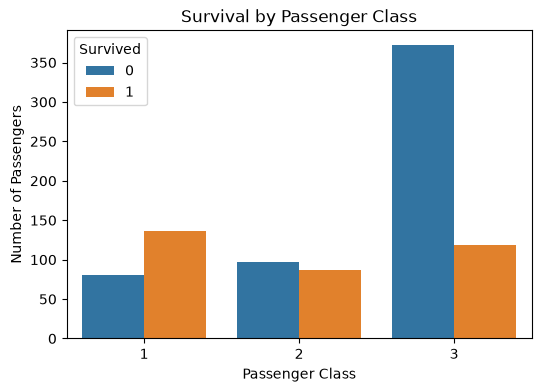

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

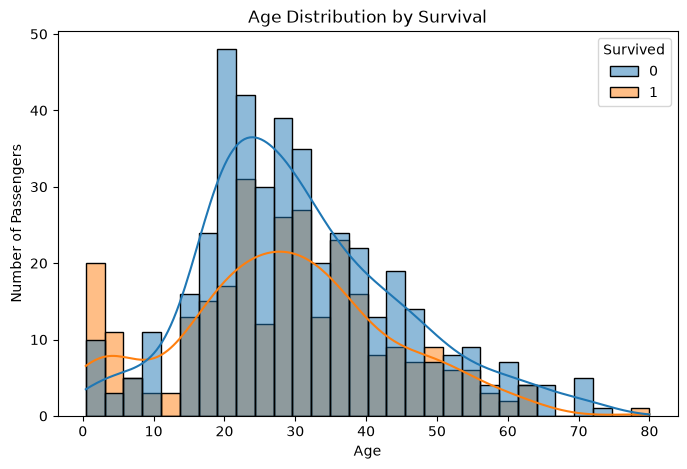

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

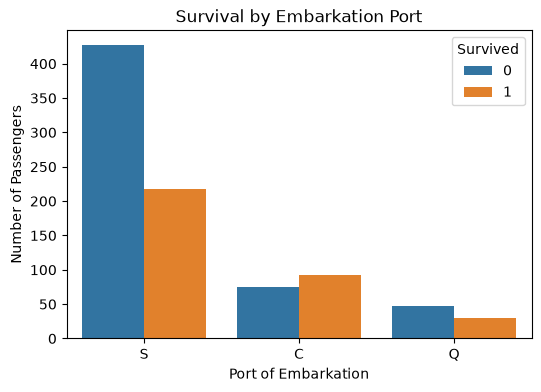

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Embarked", hue="Survived", data=df)
plt.title("Survival by Embarkation Port")
plt.xlabel("Port of Embarkation")
plt.ylabel("Number of Passengers")
plt.show()

In [39]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target:
Survived

Feature shape: (891, 7)
Target shape: (891,)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    print(f"{name} trained successfully!")

print("\nAll 5 Machine Learning models trained successfully!")

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

ml_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    ml_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

ml_results_df = pd.DataFrame(ml_results)

ml_results_df